# 🔍 EDA — PaySim Dataset
**File:** `paysim_clean.csv`  
**Purpose:** Understand PaySim's fraud patterns, transaction types, and balance signals before using it as training data.

---

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Libraries loaded')

✅ Libraries loaded


## Cell 2 — Load PaySim
Load the cleaned PaySim dataset saved earlier. This contains only TRANSFER and CASH_OUT transactions — the only types with fraud.

In [2]:
df = pd.read_csv('../data/raw/paysim_clean.csv')

print('=== PAYSIM DATASET OVERVIEW ===')
print(f'Shape              : {df.shape}  ({df.shape[0]:,} rows, {df.shape[1]} columns)')
print(f'Fraud transactions : {df["is_fraud"].sum():,}')
print(f'Fraud rate         : {df["is_fraud"].mean()*100:.4f}%')
print()
print('Columns:')
print(df.dtypes)
print()
df.head(3)

=== PAYSIM DATASET OVERVIEW ===
Shape              : (2770409, 11)  (2,770,409 rows, 11 columns)
Fraud transactions : 8,213
Fraud rate         : 0.2965%

Columns:
type                      object
amount                   float64
oldbalanceOrg            float64
newbalanceOrig           float64
oldbalanceDest           float64
newbalanceDest           float64
is_fraud                   int64
log_amount               float64
balance_diff_sender      float64
balance_diff_receiver    float64
account_drained            int64
dtype: object



,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,is_fraud,log_amount,balance_diff_sender,balance_diff_receiver,account_drained
0,TRANSFER,181.00,181.0,0.0,0.0,0.00,1,5.204007,181.0,0.00,1
1,CASH_OUT,181.00,181.0,0.0,21182.0,0.00,1,5.204007,181.0,-21182.00,1
2,CASH_OUT,229133.94,15325.0,0.0,5083.0,51513.44,0,12.342066,15325.0,46430.44,1


## Cell 3 — Missing Values Check

In [3]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(4)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print('=== MISSING VALUES ===')
print(missing_df)
print()
if missing.sum() == 0:
    print('✅ No missing values — clean dataset')
else:
    print(f'⚠️ Found {missing.sum()} missing values — investigate before training')

=== MISSING VALUES ===
                       Missing Count  Missing %
type                               0        0.0
amount                             0        0.0
oldbalanceOrg                      0        0.0
newbalanceOrig                     0        0.0
oldbalanceDest                     0        0.0
newbalanceDest                     0        0.0
is_fraud                           0        0.0
log_amount                         0        0.0
balance_diff_sender                0        0.0
balance_diff_receiver              0        0.0
account_drained                    0        0.0

✅ No missing values — clean dataset


## Cell 4 — Descriptive Statistics
Key stats for amount and balance columns.

In [4]:
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().round(2)

=== DESCRIPTIVE STATISTICS ===


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,is_fraud,log_amount,balance_diff_sender,balance_diff_receiver,account_drained
count,2770409.00,2770409.00,2770409.00,2.770409e+06,2.770409e+06,2770409.00,2770409.00,2770409.00,2.770409e+06,2770409.0
mean,317536.14,47643.08,16091.90,1.703551e+06,2.049734e+06,0.00,11.93,31551.17,3.461833e+05,0.9
std,887789.66,251325.13,151255.82,4.225550e+06,4.676990e+06,0.05,1.23,163796.94,1.177786e+06,0.3
min,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.00,-26575.26,-9.681485e+06,0.0
25%,82973.54,0.00,0.00,1.280734e+05,3.272891e+05,0.00,11.33,0.00,8.153918e+04,1.0
50%,171260.93,303.96,0.00,5.557100e+05,8.280539e+05,0.00,12.05,296.00,1.752876e+05,1.0
75%,306791.18,30997.00,0.00,1.735900e+06,2.122198e+06,0.00,12.63,26696.09,3.233030e+05,1.0
max,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,18.34,10000000.00,1.056878e+08,1.0


## Cell 5 — Fraud vs Legit Distribution
Class distribution in PaySim. Fraud rate is very low — this is the class imbalance challenge.

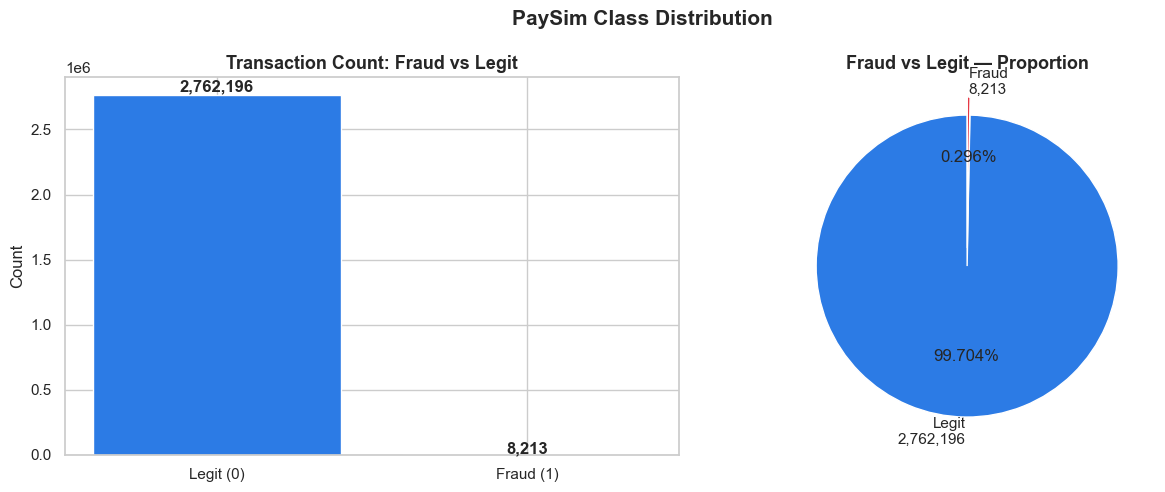

Class imbalance ratio  : 336:1  (Legit:Fraud)
Recommended scale_pos_weight for XGBoost: 336
This means fraud is extremely rare — model must be tuned carefully


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['is_fraud'].value_counts()
colors = ['#2C7BE5', '#E63946']

# Bar
axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values, color=colors, edgecolor='white')
axes[0].set_title('Transaction Count: Fraud vs Legit', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(
    counts.values,
    labels=[f'Legit\n{counts[0]:,}', f'Fraud\n{counts[1]:,}'],
    colors=colors,
    autopct='%1.3f%%',
    startangle=90,
    explode=(0, 0.12)
)
axes[1].set_title('Fraud vs Legit — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('PaySim Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = counts[0] // counts[1]
print(f'Class imbalance ratio  : {ratio}:1  (Legit:Fraud)')
print(f'Recommended scale_pos_weight for XGBoost: {ratio}')
print(f'This means fraud is extremely rare — model must be tuned carefully')

## Cell 6 — Amount Distribution: Fraud vs Legit
Are fraudulent transactions different in amount from legitimate ones?

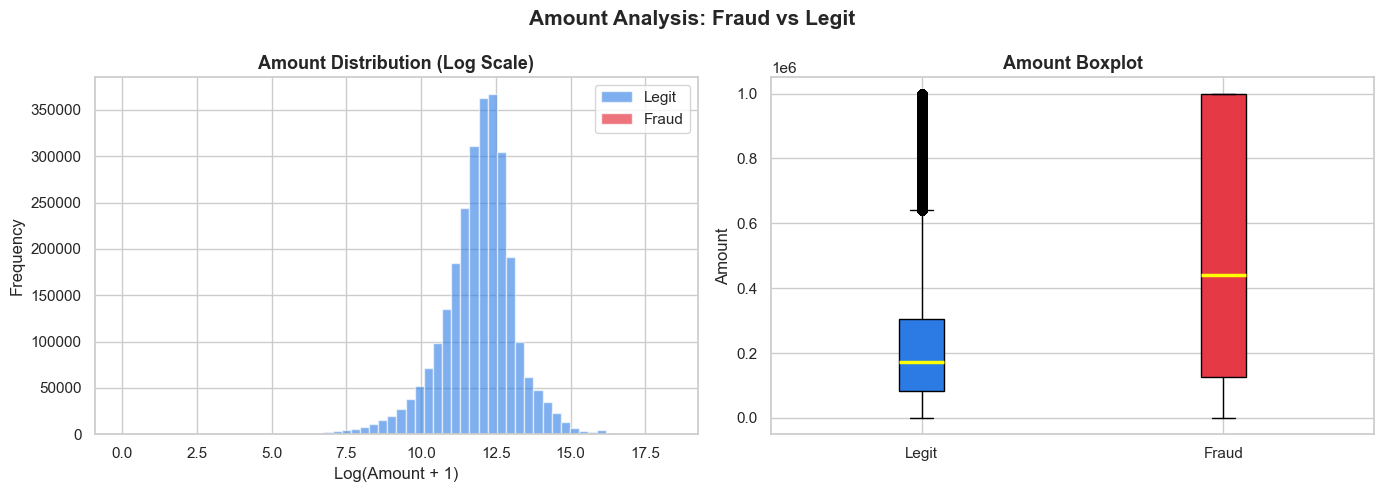

Legit  — Mean: 314,115.50 | Median: 171,034.46 | Max: 92,445,516.64
Fraud  — Mean: 1,467,967.30 | Median: 441,423.44 | Max: 10,000,000.00

Key insight: Fraud transactions tend to be LARGER than legit ones in PaySim


In [6]:
fraud = df[df['is_fraud'] == 1]['amount']
legit = df[df['is_fraud'] == 0]['amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
axes[0].hist(np.log1p(legit), bins=60, alpha=0.6, color='#2C7BE5', label='Legit')
axes[0].hist(np.log1p(fraud), bins=60, alpha=0.7, color='#E63946', label='Fraud')
axes[0].set_xlabel('Log(Amount + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Amount Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[0].legend()

# Boxplot
box_data = [
    legit.clip(upper=1000000),
    fraud.clip(upper=1000000)
]
bp = axes[1].boxplot(box_data, patch_artist=True,
                      labels=['Legit','Fraud'],
                      medianprops=dict(color='yellow', linewidth=2.5))
bp['boxes'][0].set_facecolor('#2C7BE5')
bp['boxes'][1].set_facecolor('#E63946')
axes[1].set_title('Amount Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount')

plt.suptitle('Amount Analysis: Fraud vs Legit', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Legit  — Mean: {legit.mean():,.2f} | Median: {legit.median():,.2f} | Max: {legit.max():,.2f}')
print(f'Fraud  — Mean: {fraud.mean():,.2f} | Median: {fraud.median():,.2f} | Max: {fraud.max():,.2f}')
print()
print('Key insight: Fraud transactions tend to be LARGER than legit ones in PaySim')

## Cell 7 — Transaction Type Breakdown
PaySim only has TRANSFER and CASH_OUT after filtering. Which one has more fraud?

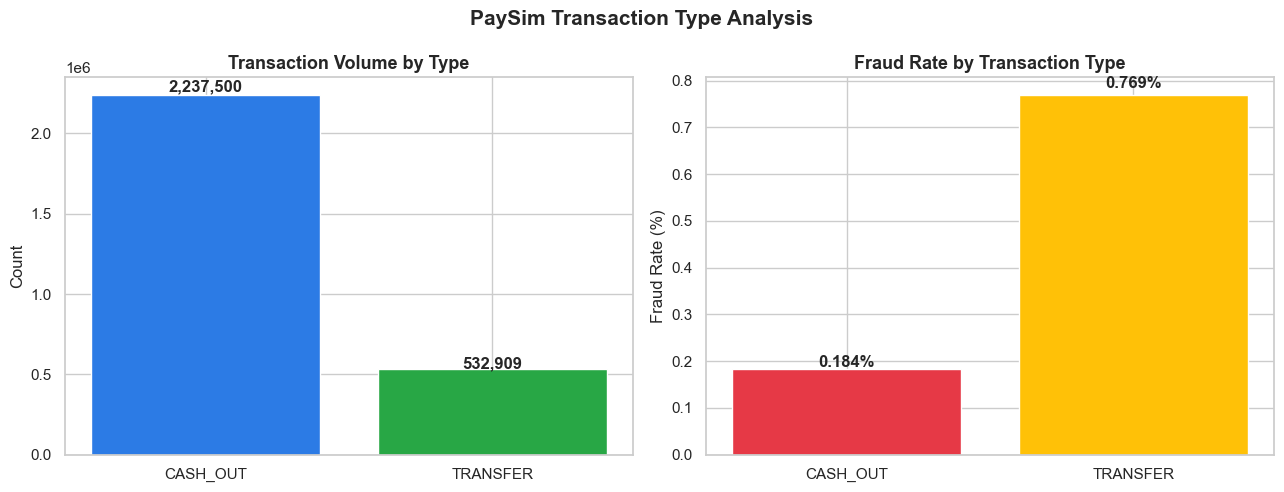

Key insight: Both TRANSFER and CASH_OUT contain fraud
This is why we kept both transaction types


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#2C7BE5','#28A745'], edgecolor='white')
axes[0].set_title('Transaction Volume by Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontweight='bold')

fraud_by_type = df.groupby('type')['is_fraud'].mean() * 100
axes[1].bar(fraud_by_type.index, fraud_by_type.values,
            color=['#E63946','#FFC107'], edgecolor='white')
axes[1].set_title('Fraud Rate by Transaction Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_by_type.values):
    axes[1].text(i, v * 1.02, f'{v:.3f}%', ha='center', fontweight='bold')

plt.suptitle('PaySim Transaction Type Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key insight: Both TRANSFER and CASH_OUT contain fraud')
print('This is why we kept both transaction types')

## Cell 8 — Balance Before vs After: Fraud Cases
The most important PaySim insight — fraudulent transactions DRAIN the sender's account to zero.

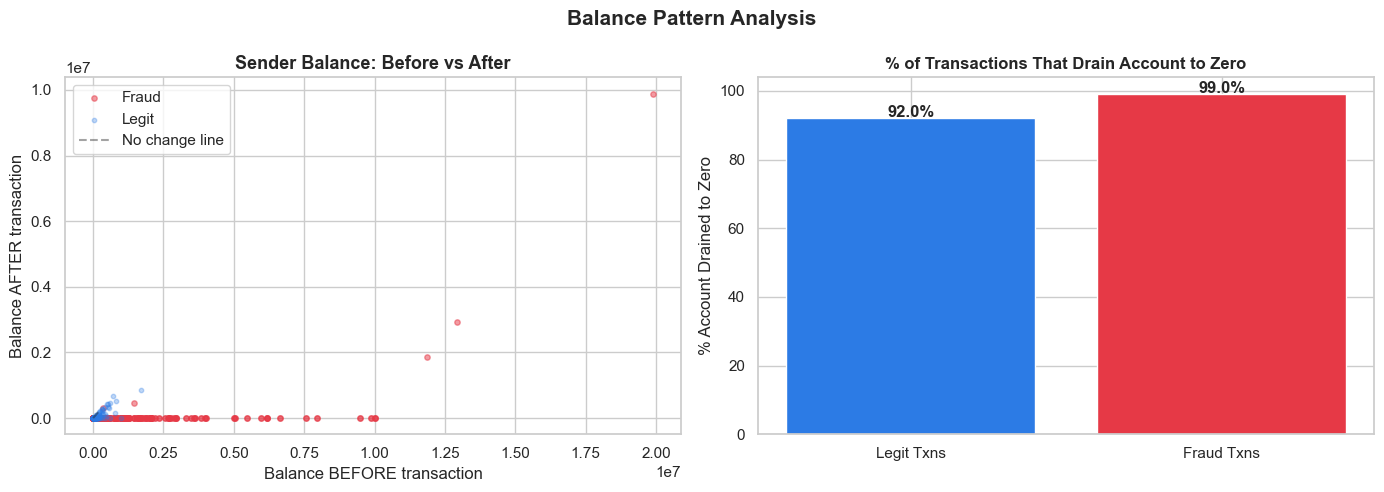

Account drained in FRAUD txns : 99.0%
Account drained in LEGIT txns : 92.0%

Key insight: Fraud transactions drain the account to 0 much more often
account_drained is a very strong fraud feature!


In [8]:
fraud_df = df[df['is_fraud'] == 1].head(500)
legit_df = df[df['is_fraud'] == 0].sample(500, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sender balance before vs after for FRAUD
axes[0].scatter(fraud_df['oldbalanceOrg'],
                fraud_df['newbalanceOrig'],
                alpha=0.5, color='#E63946', s=15, label='Fraud')
axes[0].scatter(legit_df['oldbalanceOrg'],
                legit_df['newbalanceOrig'],
                alpha=0.3, color='#2C7BE5', s=10, label='Legit')
# Line where before = after (no change)
max_val = df['oldbalanceOrg'].quantile(0.95)
axes[0].plot([0, max_val], [0, max_val], 'k--', alpha=0.4, label='No change line')
axes[0].set_xlabel('Balance BEFORE transaction')
axes[0].set_ylabel('Balance AFTER transaction')
axes[0].set_title('Sender Balance: Before vs After', fontsize=13, fontweight='bold')
axes[0].legend()

# Account drained analysis
drained_fraud = fraud_df['account_drained'].mean() * 100
drained_legit = legit_df['account_drained'].mean() * 100
axes[1].bar(['Legit Txns', 'Fraud Txns'],
            [drained_legit, drained_fraud],
            color=['#2C7BE5','#E63946'], edgecolor='white')
axes[1].set_title('% of Transactions That Drain Account to Zero',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Account Drained to Zero')
for i, v in enumerate([drained_legit, drained_fraud]):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Balance Pattern Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Account drained in FRAUD txns : {drained_fraud:.1f}%')
print(f'Account drained in LEGIT txns : {drained_legit:.1f}%')
print()
print('Key insight: Fraud transactions drain the account to 0 much more often')
print('account_drained is a very strong fraud feature!')

## Cell 9 — Balance Difference Distribution
How much money moves in fraud vs legit transactions?

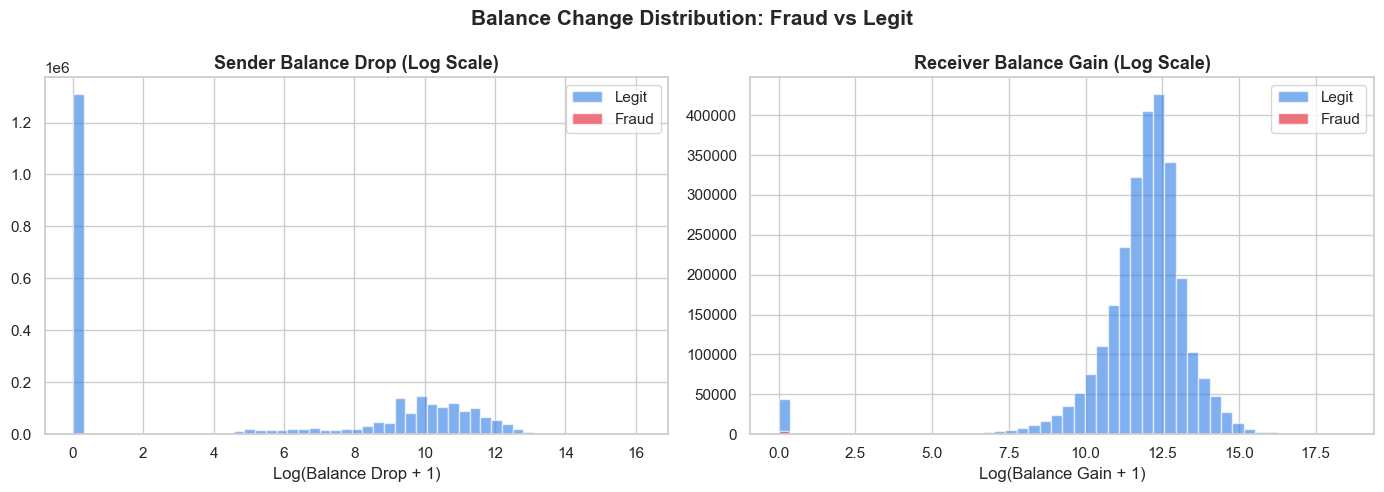

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sender balance diff
axes[0].hist(np.log1p(df[df['is_fraud']==0]['balance_diff_sender'].clip(lower=0)),
             bins=50, alpha=0.6, color='#2C7BE5', label='Legit')
axes[0].hist(np.log1p(df[df['is_fraud']==1]['balance_diff_sender'].clip(lower=0)),
             bins=50, alpha=0.7, color='#E63946', label='Fraud')
axes[0].set_title('Sender Balance Drop (Log Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Log(Balance Drop + 1)')
axes[0].legend()

# Receiver balance diff
axes[1].hist(np.log1p(df[df['is_fraud']==0]['balance_diff_receiver'].clip(lower=0)),
             bins=50, alpha=0.6, color='#2C7BE5', label='Legit')
axes[1].hist(np.log1p(df[df['is_fraud']==1]['balance_diff_receiver'].clip(lower=0)),
             bins=50, alpha=0.7, color='#E63946', label='Fraud')
axes[1].set_title('Receiver Balance Gain (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Balance Gain + 1)')
axes[1].legend()

plt.suptitle('Balance Change Distribution: Fraud vs Legit', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 10 — Correlation Heatmap

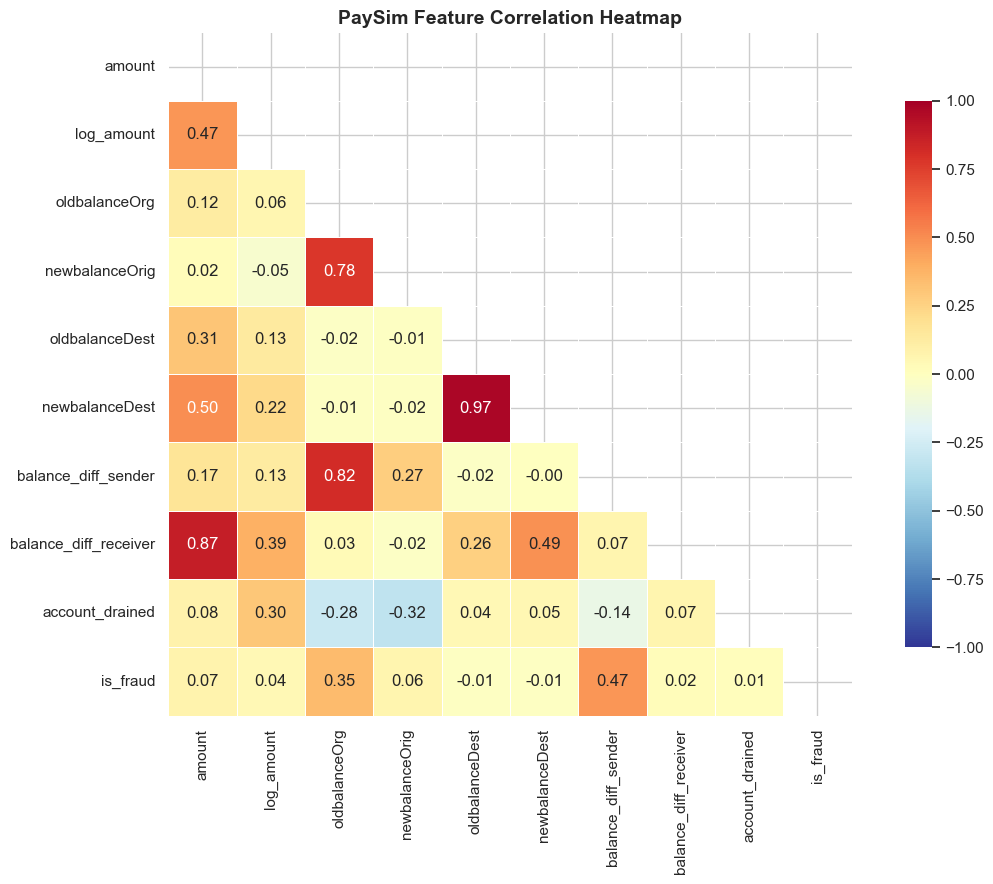

=== CORRELATION WITH is_fraud (sorted) ===
balance_diff_sender      0.474628
oldbalanceOrg            0.347582
amount                   0.070660
newbalanceOrig           0.063557
log_amount               0.042649
balance_diff_receiver    0.018022
account_drained          0.014496
newbalanceDest          -0.008978
oldbalanceDest          -0.014960
Name: is_fraud, dtype: float64


In [10]:
corr_cols = ['amount','log_amount','oldbalanceOrg','newbalanceOrig',
             'oldbalanceDest','newbalanceDest',
             'balance_diff_sender','balance_diff_receiver',
             'account_drained','is_fraud']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('PaySim Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== CORRELATION WITH is_fraud (sorted) ===')
print(corr_matrix['is_fraud'].drop('is_fraud').sort_values(ascending=False))

## Cell 11 — Account Drained Flag Analysis
Deep dive into the `account_drained` feature — accounts that are fully emptied in one transaction.

=== ACCOUNT DRAINED FLAG ANALYSIS ===
                         fraud_count  total_count  fraud_rate
Not Drained                      160       273753      0.0584
Account Drained to Zero         8053      2496656      0.3226



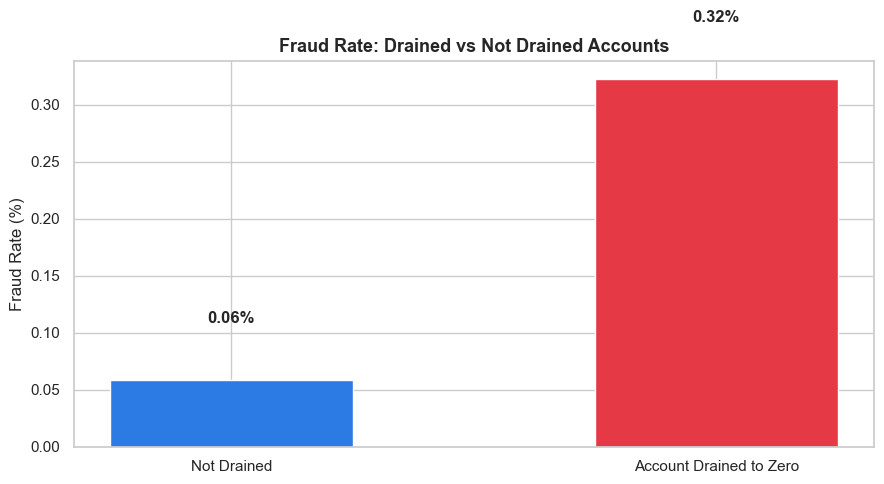

In [11]:
drained_summary = df.groupby('account_drained')['is_fraud'].agg(['sum','count','mean'])
drained_summary.columns = ['fraud_count','total_count','fraud_rate']
drained_summary['fraud_rate'] = drained_summary['fraud_rate'] * 100
drained_summary.index = ['Not Drained','Account Drained to Zero']

print('=== ACCOUNT DRAINED FLAG ANALYSIS ===')
print(drained_summary.round(4))
print()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    drained_summary.index,
    drained_summary['fraud_rate'],
    color=['#2C7BE5','#E63946'],
    edgecolor='white', width=0.5
)
ax.set_title('Fraud Rate: Drained vs Not Drained Accounts',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
for bar, v in zip(bars, drained_summary['fraud_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
            f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 12 — Summary Insights

In [12]:
print('=' * 55)
print('         EDA SUMMARY — PAYSIM DATASET')
print('=' * 55)
print(f'Total transactions    : {len(df):,}')
print(f'Fraud transactions    : {df["is_fraud"].sum():,} ({df["is_fraud"].mean()*100:.4f}%)')
print(f'Avg fraud amount      : {df[df["is_fraud"]==1]["amount"].mean():,.2f}')
print(f'Avg legit amount      : {df[df["is_fraud"]==0]["amount"].mean():,.2f}')
print(f'Transaction types     : {df["type"].unique().tolist()}')
print()
print('KEY INSIGHTS FOR MODEL TRAINING:')
print('-' * 55)
print('1. Extreme class imbalance — use scale_pos_weight')
print('2. Fraud txns have HIGHER amounts than legit')
print('3. account_drained is a strong fraud signal')
print('4. balance_diff features correlated with fraud')
print('5. Both TRANSFER and CASH_OUT contain fraud')
print('6. log_amount better than raw amount for modelling')
print('=' * 55)

         EDA SUMMARY — PAYSIM DATASET
Total transactions    : 2,770,409
Fraud transactions    : 8,213 (0.2965%)
Avg fraud amount      : 1,467,967.30
Avg legit amount      : 314,115.50
Transaction types     : ['TRANSFER', 'CASH_OUT']

KEY INSIGHTS FOR MODEL TRAINING:
-------------------------------------------------------
1. Extreme class imbalance — use scale_pos_weight
2. Fraud txns have HIGHER amounts than legit
3. account_drained is a strong fraud signal
4. balance_diff features correlated with fraud
5. Both TRANSFER and CASH_OUT contain fraud
6. log_amount better than raw amount for modelling
